## 1. Importing libraries

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from gensim.models import Word2Vec
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

## 2. Loading Data

In [2]:
df = pd.read_csv("../data/raw/spam.csv", encoding="latin-1")
print(df.head())

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


## 3. Exploratory Data Analysis

In [3]:
print(f"Dataset shape: {df.shape}")
print(f"\nDataset column names: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n {df.isnull().sum()}")
print(f"\nFirst 5 rows: \n{df.head()}")

Dataset shape: (5572, 5)

Dataset column names: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Data types:
v1            object
v2            object
Unnamed: 2    object
Unnamed: 3    object
Unnamed: 4    object
dtype: object

Missing values:
 v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

First 5 rows: 
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [4]:
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])

In [5]:
df = df.rename(columns={"v1": "label", "v2": "sms-text"})
print(f"\nDataset column names: {df.columns.tolist()}")
print(f"Dataset shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")


Dataset column names: ['label', 'sms-text']
Dataset shape: (5572, 2)

Data types:
label       object
sms-text    object
dtype: object


In [6]:
print("Class distribution:")
print(df["label"].value_counts())
print("\nClass distribution percentage:")
print(df["label"].value_counts(normalize=True) * 100)
print("\n")

Class distribution:
ham     4825
spam     747
Name: label, dtype: int64

Class distribution percentage:
ham     86.593683
spam    13.406317
Name: label, dtype: float64




In [7]:
print("Sample Spam SMS-Message:")
print(df[df["label"] == "spam"]["sms-text"].iloc[0])
print("\n")
print("Sample Ham SMS-Message:")
print(df[df["label"] == "ham"]["sms-text"].iloc[2])


Sample Spam SMS-Message:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's


Sample Ham SMS-Message:
U dun say so early hor... U c already then say...


In [8]:
# Create length features 
df['char_count'] = df['sms-text'].str.len()
df['word_count'] = df['sms-text'].str.split().apply(len)

# Check stastistics by class
print(df.groupby('label').agg({'char_count': 'mean', 'word_count': 'mean'}))

       char_count  word_count
label                        
ham     71.023627   14.200622
spam   138.866131   23.851406


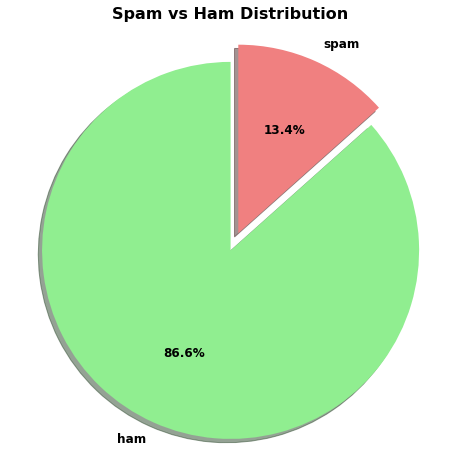

<Figure size 432x288 with 0 Axes>

In [9]:
# Get value counts
label_counts = df['label'].value_counts()

# Create pie chart
plt.figure(figsize=(8, 8))
colors = ['lightgreen', 'lightcoral']
explode = (0.05, 0.05)  # Slightly separate the slices

plt.pie(label_counts.values, 
        labels=label_counts.index, 
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        explode=explode,
        shadow=True,
        textprops={'fontsize': 12, 'fontweight': 'bold'})

plt.title('Spam vs Ham Distribution', fontsize=16, fontweight='bold')
plt.axis('equal')  # Equal aspect ratio ensures circular pie
plt.show()
plt.savefig('../results/plots/spam_vs_ham_class_distribution.png')

In [10]:
spam_count = (df['label'] == 'spam').sum()
ham_count = (df['label'] == 'ham').sum()

# Calculate imbalance ratio
imbalance_ratio = ham_count / spam_count
print("="*50)
print("CLASS IMBALANCE ANALYSIS")
print("="*50)
print(f"Ham messages: {ham_count}")
print(f"Spam messages: {spam_count}")
print(f"Total messages: {len(df)}")
print(f"\nImbalance Ratio (Ham:Spam): {imbalance_ratio:.2f}:1")
print(f"This means there are {imbalance_ratio:.2f} ham messages for every 1 spam message")
print(f"Models trained on imbalanced data may perform poorly on spam detection")
print("="*50)

CLASS IMBALANCE ANALYSIS
Ham messages: 4825
Spam messages: 747
Total messages: 5572

Imbalance Ratio (Ham:Spam): 6.46:1
This means there are 6.46 ham messages for every 1 spam message
Models trained on imbalanced data may perform poorly on spam detection


In [11]:
spam_messages = df[df['label'] == 'spam']['sms-text']
ham_messages = df[df['label'] == 'ham']['sms-text']

combined_spam_message = ' '.join(spam_messages).lower()
combined_ham_message = ' '.join(ham_messages).lower()

print(f"\nCombined Spam Message:\n{combined_spam_message}")
print(f"\nCombined Ham Message:\n{combined_ham_message}")

spam_words = combined_spam_message.split()
ham_words = combined_ham_message.split()

spam_word_counts = Counter(spam_words)
ham_word_counts = Counter(ham_words)

spam_df = pd.DataFrame({
    'word': spam_word_counts.keys(),
    'count': spam_word_counts.values()
})

ham_df = pd.DataFrame({
    'word': ham_word_counts.keys(),
    'count': ham_word_counts.values()
})

spam_df = spam_df.sort_values(by='count', ascending=False)
ham_df = ham_df.sort_values(by='count', ascending=False)

print(f"\nTop 20 Spam Words:\n{spam_df.head(20)}")
print(f"\nTop 20 Ham Words:\n{ham_df.head(20)}")


Combined Spam Message:
free entry in 2 a wkly comp to win fa cup final tkts 21st may 2005. text fa to 87121 to receive entry question(std txt rate)t&c's apply 08452810075over18's freemsg hey there darling it's been 3 week's now and no word back! i'd like some fun you up for it still? tb ok! xxx std chgs to send, å£1.50 to rcv winner!! as a valued network customer you have been selected to receivea å£900 prize reward! to claim call 09061701461. claim code kl341. valid 12 hours only. had your mobile 11 months or more? u r entitled to update to the latest colour mobiles with camera for free! call the mobile update co free on 08002986030 six chances to win cash! from 100 to 20,000 pounds txt> csh11 and send to 87575. cost 150p/day, 6days, 16+ tsandcs apply reply hl 4 info urgent! you have won a 1 week free membership in our å£100,000 prize jackpot! txt the word: claim to no: 81010 t&c www.dbuk.net lccltd pobox 4403ldnw1a7rw18 xxxmobilemovieclub: to use your credit, click the wap link in t

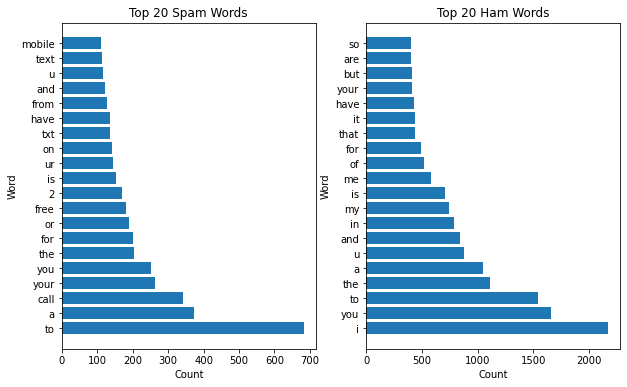

<Figure size 432x288 with 0 Axes>

In [12]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.barh(spam_df['word'][:20], spam_df['count'][:20])
plt.title('Top 20 Spam Words')
plt.xlabel('Count')
plt.ylabel('Word')
plt.subplot(1,2,2)
plt.barh(ham_df['word'][:20], ham_df['count'][:20:])
plt.title('Top 20 Ham Words')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()
plt.savefig('../results/plots/top_20_words.png')

We notice that the top words are not meaningful and they're mostly stop words. The only word that is meaningful is "free" in the spam messages but for now we really can't differentiate between spam and ham.

In [13]:
!pip install wordcloud
!pip install --upgrade pip
!pip install --upgrade Pillow

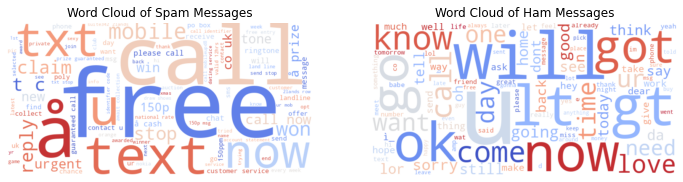

<Figure size 432x288 with 0 Axes>

In [14]:
from wordcloud import WordCloud

spam_word_cloud = WordCloud(width=800, height=400, background_color='white',max_words=100, colormap='coolwarm').generate(combined_spam_message)
ham_word_cloud = WordCloud(width=800, height=400, background_color='white',max_words=100, colormap='coolwarm').generate(combined_ham_message)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(spam_word_cloud, interpolation='bilinear')
plt.title('Word Cloud of Spam Messages')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(ham_word_cloud, interpolation='bilinear')
plt.title('Word Cloud of Ham Messages')
plt.axis('off')
plt.show()
plt.savefig('../results/plots/wordcloud.png')


In [15]:
# Special Character Analysis
df['has_url'] = df['sms-text'].str.contains('http|https|www', case=False).astype(int)
df['has_currency'] = df['sms-text'].str.contains('[$€£]', case=False).astype(int)
df['has_phone_number'] = df['sms-text'].str.contains(r'\d{10,}', regex=True).astype(int) # check for 10+ digits

print("Feature presence by class: \n")
print(df.groupby('label')[['has_url', 'has_currency', 'has_phone_number']].mean() * 100)

Feature presence by class: 

         has_url  has_currency  has_phone_number
label                                           
ham     0.062176      0.373057          0.020725
spam   14.323963     34.404284         54.216867


In [16]:
# N-gram Analysis
def get_top_ngrams(corpus, n=2, top_k=20):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english')

    bag_of_words = vec.fit_transform(corpus)
    
    sum_words = bag_of_words.sum(axis=0) 
    
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]

    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    return pd.DataFrame(words_freq[:top_k], columns=['ngram', 'Count'])


In [17]:
spam_ngram = get_top_ngrams(spam_messages, n=2, top_k=20)
ham_ngram = get_top_ngrams(ham_messages, n=2, top_k=20)

print("Top 20 N-grams in Spam Messages:")
print(spam_ngram)

print("\nTop 20 N-grams in Ham Messages:")
print(ham_ngram)

Top 20 N-grams in Spam Messages:
                ngram  Count
0              po box     24
1           1000 cash     23
2    prize guaranteed     22
3           send stop     20
4       national rate     20
5    selected receive     19
6    await collection     19
7       urgent mobile     18
8           land line     18
9    customer service     17
10        valid 12hrs     17
11           150p msg     17
12        prize claim     17
13         chance win     17
14         free entry     16
15  account statement     16
16    identifier code     16
17           txt stop     16
18           txt word     15
19     trying contact     15

Top 20 N-grams in Ham Messages:
           ngram  Count
0          lt gt    276
1       ll later     42
2       let know     40
3       sorry ll     39
4   good morning     32
5       don know     24
6     lt decimal     23
7     decimal gt     23
8       new year     23
9       pls send     22
10        ok lor     22
11    good night     19
12      just 

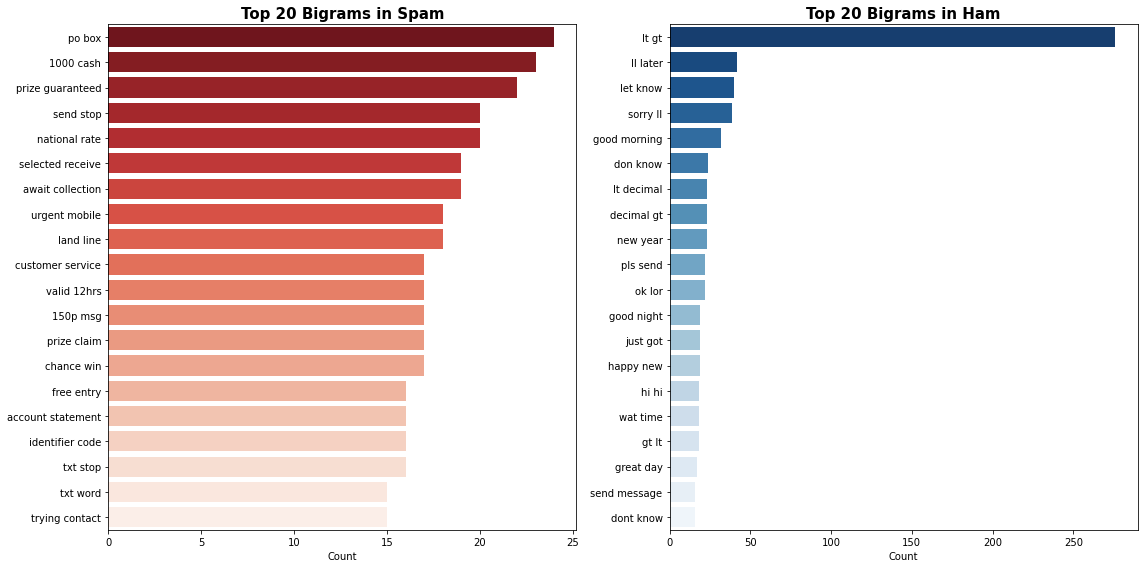

<Figure size 432x288 with 0 Axes>

In [18]:
def plot_ngrams(spam_ngrams, ham_ngrams, title_prefix="Bigrams"):
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    sns.barplot(x='Count', y='ngram', data=spam_ngram, ax=axes[0], palette='Reds_r')
    axes[0].set_title(f'Top 20 {title_prefix} in Spam', fontsize=15, fontweight='bold')
    axes[0].set_xlabel('Count')
    axes[0].set_ylabel('')

    sns.barplot(x='Count', y='ngram', data=ham_ngram, ax=axes[1], palette='Blues_r')
    axes[1].set_title(f'Top 20 {title_prefix} in Ham', fontsize=15, fontweight='bold')
    axes[1].set_xlabel('Count')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

plot_ngrams(spam_ngram, ham_ngram, title_prefix="Bigrams")
plt.savefig('../results/plots/bigrams.png')


## EDA Conclusion

Based on our exploratory analysis, we have identified several key patterns that distinguish spam from ham:

1. **Class Imbalance:** The dataset is highly imbalanced (87% Ham vs 13% Spam). We will need to address this during model training.
2. **Message Length:** Spam messages tend to be longer (avg 138 vs 71 characters).
3. **Keywords:** Spam is dominated by promotional words like "FREE", "call", "txt", "claim", "prize".
4. **Special Characters:** Spam has high usage of URLs, currency symbols, and phone numbers.
5. **N-grams:** Phrases like "prize claim" and "urgent mobile" are strong predictors.

### Next Steps:
- Implement a **Preprocessing Pipeline** (Stopword removal, Lemmatization).
- Create **Engineering Features** based on our findings.

## EDA Conclusion

Based on our exploratory analysis, we have identified several key patterns that distinguish spam from ham:

1. **Class Imbalance:** The dataset is highly imbalanced (87% Ham vs 13% Spam). We will need to address this during model training.
2. **Message Length:** Spam messages tend to be longer (avg 138 vs 71 characters).
3. **Keywords:** Spam is dominated by promotional words like "FREE", "call", "txt", "claim", "prize".
4. **Special Characters:** Spam has high usage of URLs, currency symbols, and phone numbers.
5. **N-grams:** Phrases like "prize claim" and "urgent mobile" are strong predictors.

### Next Steps:
- Implement a **Preprocessing Pipeline** (Stopword removal, Lemmatization).
- Create **Engineering Features** based on our findings.

## 4. Preprocessing Data

In [19]:
import os
import sys
sys.path.append(os.path.abspath('..'))

In [20]:
import nltk
from nltk import pos_tag
from nltk.tokenize import word_tokenize
from nltk import ne_chunk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('maxent_ne_chunker', quiet=True)
nltk.download('words', quiet=True)

True

In [21]:
from src.preprocessing import clean_text, tokenize, remove_stopwords, lemmatize

def preprocess_pipeline(text):
    text = clean_text(text)
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize(tokens)
    return " ".join(tokens)


print("Preprocessing data... this may take a moment.")
df['processed_text'] = df['sms-text'].apply(preprocess_pipeline)
print("Done!")
# 6. Show the Difference
print("\nSample Comparison:")
print(df[['sms-text', 'processed_text']].head())

Preprocessing data... this may take a moment.
Done!

Sample Comparison:
                                            sms-text  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                      processed_text  
0  go jurong point crazy available bugis n great ...  
1                            ok lar joking wif u oni  
2  free entry wkly comp win fa cup final tkts st ...  
3                u dun say early hor u c already say  
4           nah dont think go usf life around though  


## 5. Linguistic Analysis

In [22]:
def get_pos_tags(text):
    tokens = word_tokenize(text)
    tagged_tokens = pos_tag(tokens)
    tags = [tag for word, tag in tagged_tokens]
    return tags

df['pos_tags'] = df['sms-text'].apply(get_pos_tags)
print(df[['sms-text','pos_tags']].head())


                                            sms-text  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                            pos_tags  
0  [NNP, IN, JJ, NN, ,, JJ, NN, NNP, RB, IN, NN, ...  
1                  [NNP, NN, :, NNP, WRB, JJ, NN, :]  
2  [JJ, NN, IN, CD, DT, JJ, NN, TO, VB, NNP, NNP,...  
3  [JJ, NNS, VBP, RB, JJ, NN, :, NNP, VBP, RB, RB...  
4  [NNP, PRP, VBP, RB, VB, PRP, VBZ, TO, VB, ,, P...  


### (POS) Tagging Analysis

We have tagged each word with its grammatical role using NLTK's `averaged_perceptron_tagger`. The common tags include:

- **NN / NNS / NNP:** Noun (singular/plural) - *e.g., "prize", "winner"*
- **VB / VBP / VBG:** Verb (base/present/gerund) - *e.g., "call", "win", "running"*
- **JJ:** Adjective - *e.g., "free", "urgent"*
- **PRP:** Pronoun - *e.g., "you", "me"*
- **CD:** Cardinal Number - *e.g., "1000", "50"*

**Goal:**
We can now analyze if **Spam** messages rely more heavily on specific parts of speech (like Verbs and Numbers) compared to **Ham** messages (which might use more Pronouns and Nouns).

In [23]:
def extract_entities(text):
    entities = []
    tags = pos_tag(word_tokenize(text))
    tree = ne_chunk(tags)

    for chunk in tree:
        if hasattr(chunk, 'label'):
            entity_name = ' '.join(c[0] for c in chunk)
            entity_label = chunk.label()
            entities.append((entity_name, entity_label))
    return entities

In [25]:
print("Extracting entities... (Please wait)")
df['entities'] = df['sms-text'].apply(extract_entities)
print("Done!")

spam_entities = [ent for sublist in df[df['label'] == 'spam']['entities'] for ent in sublist]
ham_entities = [ent for sublist in df[df['label'] == 'ham']['entities'] for ent in sublist]

print("\nTop 10 Entities in SPAM :")
print(Counter(spam_entities).most_common(10))
print("\nTop 10 Entities in HAM :")
print(Counter(ham_entities).most_common(10))

Extracting entities... (Please wait)
Done!

Top 10 Entities in SPAM :
[(('URGENT', 'ORGANIZATION'), 34), (('FREE', 'ORGANIZATION'), 31), (('GUARANTEED', 'ORGANIZATION'), 22), (('Text', 'PERSON'), 18), (('Txt', 'PERSON'), 17), (('Free', 'GPE'), 16), (('SAE', 'ORGANIZATION'), 16), (('CASH', 'ORGANIZATION'), 12), (('Orange', 'GPE'), 12), (('UK', 'ORGANIZATION'), 11)]

Top 10 Entities in HAM :
[(('Sorry', 'PERSON'), 111), (('Ok', 'GPE'), 56), (('Good', 'GPE'), 39), (('Hi', 'GPE'), 34), (('Yup', 'GPE'), 28), (('Haha', 'GPE'), 25), (('Hey', 'GPE'), 24), (('Hello', 'GPE'), 23), (('DECIMAL', 'ORGANIZATION'), 23), (('Aight', 'GPE'), 21)]


### Named Entity Recognition (NER) Analysis

We extracted named entities to see if Spam messages reference specific organizations or people.

#### **Key Findings:**
1.  **Capitalization Bias:** The NER model (trained on formal news text) struggles with SMS slang. It misclassifies capitalized words like "FREE", "URGENT" as **ORGANIZATIONS** and "Sorry", "Ok" as **PEOPLE/LOCATIONS**.
2.  **Spam Indicators:** Despite the misclassification, the "Entities" found in spam are highly predictive:
    *   **Urgency:** `URGENT`, `GUARANTEED`, `CASH`
    *   **Promotional:** `FREE`, `SAE` (Self Addressed Envelope)
    *   **Brands:** `Orange`, `Nokia` (often appear in spam contests)
3.  **Ham Indicators:** Ham entities are purely conversational (`Sorry`, `Ok`, `Hi`, `Haha`) or personal names.

**Conclusion:**
While standard NER labels are unreliable on this dataset, the **presence of capitalized keywords** (which the NER model picks up) is a strong feature for detecting spam.

## 6. Feature Engineering

In [26]:
vectorizer = TfidfVectorizer(max_features=3000)
X = vectorizer.fit_transform(df['processed_text']).toarray()
y = df['label'].map({'ham': 0, 'spam': 1}).values
print(X.shape, y.shape)

(5572, 3000) (5572,)


## 7. Model Training

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training Data: {X_train.shape}")
print(f"Testing Data: {X_test.shape}")

Training Data: (4457, 3000)
Testing Data: (1115, 3000)


## Naive Bayes

In [28]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred = nb_model.predict(X_test)

print(f"Classification report:\n {classification_report(y_test, y_pred)}")
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Classification report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       1.00      0.84      0.91       150

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115

Accuracy: 0.97847533632287


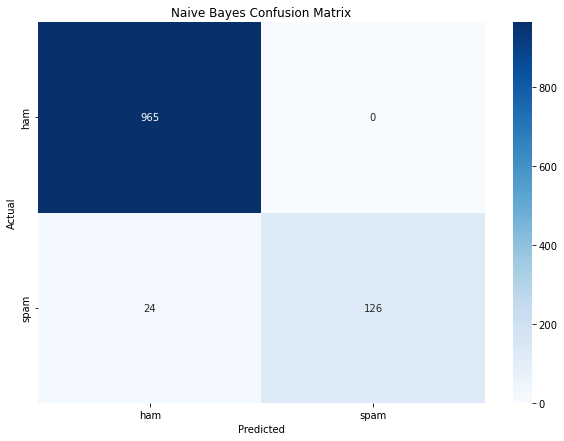

<Figure size 432x288 with 0 Axes>

In [78]:
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes Confusion Matrix')
plt.show()
plt.savefig('../results/plots/naive_bayes_confusion_matrix.png')

In [30]:
X_train_txt, X_test_txt, _, _ = train_test_split(df['sms-text'], y, test_size=0.2, random_state=42, stratify=y)

results = pd.DataFrame({
    'text': X_test_txt.values, #Note: X_test_txt is the original text data 
    'true_label': y_test,
    'predicted_label': y_pred
})

false_negatives = results[(results['true_label'] == 1) & (results['predicted_label'] == 0)]
print(f"Found {len(false_negatives)} false negatives.")
print("\n--- Top 5 Sneaky Spams ---")
for text in false_negatives['text'][:5]:
    print(f"{text}\n")
    print("---")

Found 24 false negatives.

--- Top 5 Sneaky Spams ---
Fffff. Can you text kadeem or are you too far gone

---
U R THE MOST BEAUTIFUL GIRL IVE EVER SEEN. U R MY BABY COME AND C ME IN THE COMMON ROOM

---
Hello. Damn this christmas thing. I think i have decided to keep this mp3 that doesnt work.

---
Nothing. I meant that once the money enters your account here, the bank will remove its flat rate. Someone transfered  &lt;#&gt;  to my account and  &lt;#&gt; dollars got removed. So the banks differ and charges also differ.be sure you trust the 9ja person you are sending account details to cos...

---
Its just the effect of irritation. Just ignore it

---


## Random Forest

In [31]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print(f"Classification report:\n {classification_report(y_test, y_pred_rf)}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}")

Classification report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       965
           1       1.00      0.83      0.91       150

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.95      1115
weighted avg       0.98      0.98      0.98      1115

Accuracy: 0.9766816143497757


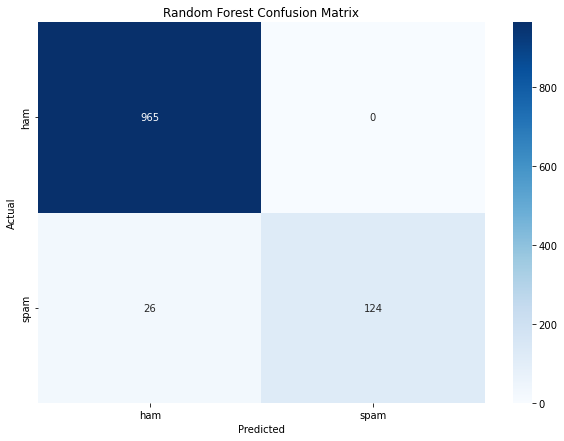

In [32]:
conf_mat_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(10,7))
sns.heatmap(conf_mat_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

## SVM

In [33]:
svm_model = SVC(kernel='sigmoid', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print(f"Classification report:\n {classification_report(y_test, y_pred_svm)}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm)}")

Classification report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.97      0.85      0.90       150

    accuracy                           0.98      1115
   macro avg       0.97      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115

Accuracy: 0.9757847533632287


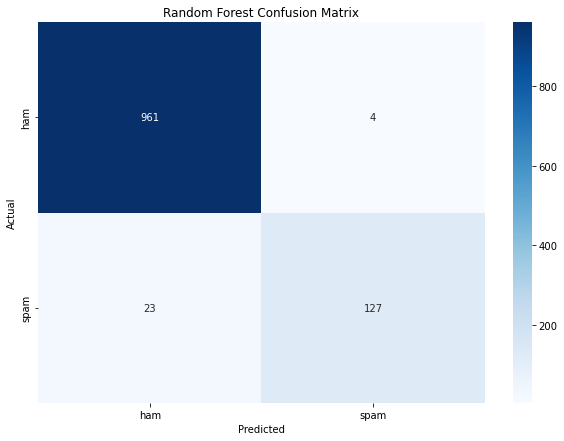

<Figure size 432x288 with 0 Axes>

In [77]:
conf_mat_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(10,7))
sns.heatmap(conf_mat_svm, annot=True, fmt='d', cmap='Blues', xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()
plt.savefig('../results/plots/confusion_matrix_svm.png')

## Model Evaluation & Comparison (Phase 1)

We trained three different models using TF-IDF features. Here is the performance summary:

| Model | Accuracy | Precision (Spam) | Recall (Spam) | F1-Score (Spam) |
|-------|----------|------------------|---------------|-----------------|
| **Naive Bayes** | **97.85%** | **1.00** | 0.84 | **0.91** |
| Random Forest | 97.67% | **1.00** | 0.83 | 0.91 |
| SVM (Sigmoid) | 97.58% | 0.97 | **0.85** | 0.90 |

### **Conclusion:**
- **Winner:** **Multinomial Naive Bayes** is the best performing model overall.
- **Why?** It achieves the highest accuracy and, crucially, **Perfect Precision**. In a spam detection context, False Positives (blocking a real email) are much worse than False Negatives (letting a spam through). Naive Bayes ensures 0 legitimate emails are blocked.
- **Trade-off:** SVM caught slightly more spam (Recall 0.85), but made some mistakes on legitimate mail.

### **Next Steps (Phase 2):**
To improve the **Recall** (catch the "sneaky spam" like the Nigerian Prince scam) without losing Precision, we will try **Deep Learning with Word Embeddings (Word2Vec)** to capture context.

## Word Embeddings using Word2Vec

In [35]:
sentences = [text.split() for text in df['processed_text']]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)

In [36]:
word = 'prize'
if word in w2v_model.wv:
    print(f"\nMost similar words to '{word}':")
    print(w2v_model.wv.most_similar(word))
else:
    print(f"The word '{word}' is not in the vocabulary.")


Most similar words to 'prize':
[('guaranteed', 0.9988088011741638), ('å£', 0.998537003993988), ('claim', 0.9983276128768921), ('cash', 0.9981686472892761), ('award', 0.9972802400588989), ('draw', 0.9972473382949829), ('awarded', 0.9969860315322876), ('urgent', 0.9967913627624512), ('call', 0.9965910911560059), ('valid', 0.9965426325798035)]


## Tokenization and Padding

In [51]:
MAX_WORDS = 1000 # We'll use the top 1000 words
MAX_LEN = 100 # Every message will be truncated to 100 words

tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(df['processed_text'])
sequences = tokenizer.texts_to_sequences(df['processed_text'])

X_seq = pad_sequences(sequences, maxlen=MAX_LEN)
y_seq = df['label'].map({'ham': 0, 'spam': 1}).values

print(f"Originial: {df['processed_text'][0]}")
print(f"Sequence: {sequences[0]}")
print(f"Shape: {X_seq.shape}")
print(f"Label shape: {y_seq.shape}")

Originial: go jurong point crazy available bugis n great world la e buffet cine got amore wat
Sequence: [6, 269, 576, 549, 40, 61, 250, 878, 87, 16, 73]
Shape: (5572, 100)
Label shape: (5572,)


## Bidirectional LSTM

In [70]:
model_tuned = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=MAX_WORDS, output_dim=50),
    Bidirectional(LSTM(32, kernel_regularizer=l2(0.01))),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_tuned.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_tuned.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ (None, 100, 50)        │        50,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 64)             │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,313 (278.57 KB)

 Trainable params: 71,313 (278.57 KB)

 Non-trainable params: 0 (0.00 B)

In [71]:
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(X_seq, y_seq, test_size=0.3, random_state=42, stratify=y_seq)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

print("Training LSTM Model ...")
history = model_tuned.fit(
    X_train_seq,
    y_train_seq,
    epochs=30,
    batch_size=32,
    validation_data=(X_test_seq, y_test_seq),
    callbacks=[early_stop],
    verbose=1
)

loss, accuracy = model_tuned.evaluate(X_test_seq, y_test_seq)
print(f"\nFinal Test Accuracy : {accuracy*100:.2f}%")

Training LSTM Model ...
Epoch 1/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8594 - loss: 1.3693 - val_accuracy: 0.9563 - val_loss: 0.3636
Epoch 2/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9688 - loss: 0.2618 - val_accuracy: 0.9731 - val_loss: 0.1262
Epoch 3/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9789 - loss: 0.1032 - val_accuracy: 0.9785 - val_loss: 0.0980
Epoch 4/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9869 - loss: 0.0712 - val_accuracy: 0.9803 - val_loss: 0.0922
Epoch 5/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9874 - loss: 0.0654 - val_accuracy: 0.9803 - val_loss: 0.0836
Epoch 6/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9944 - loss: 0.0379 - val_accuracy: 0.9833 - val_loss: 0.0801
Epoch 7/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9937 - loss: 0.0362 - val_accuracy: 0.9827 - val_loss: 0.0808
Epoch 8/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9920 -

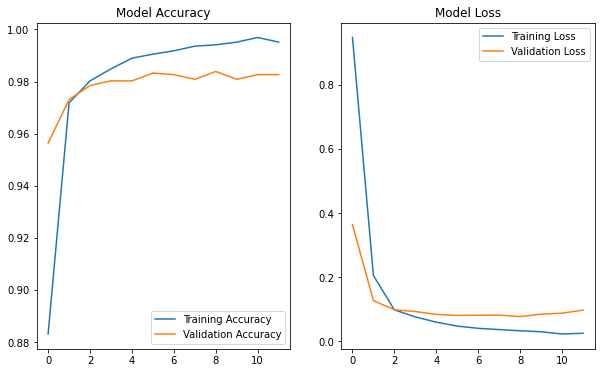

<Figure size 432x288 with 0 Axes>

In [76]:
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy']    , label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss']    , label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.legend()
plt.show()
plt.savefig('../results/plots/model_history.png')

## 9. Model Export

In [73]:
model_tuned.save('../models/best_spam_detect_model.h5')
print("Saved optimized model to models/best_spam_detect_model.h5")

Saved optimized model to models/best_spam_detect_model.h5


In [75]:
with open('../models/tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

print("Saved tokenizer to models/tokenizer.pickle")

Saved tokenizer to models/tokenizer.pickle
